In [1]:
# 1. Standard library imports
import logging
import math
import os
import re
import json
import time
from typing import Dict, List, Optional, Tuple
from pathlib import Path

# 2. Related third-party imports
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
from tqdm import tqdm
import tiktoken


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo
def show_vram_usage():
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info = nvmlDeviceGetMemoryInfo(handle)
    return str(f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB")

In [4]:
print(show_vram_usage())

Used: 663 MB, Free: 11624 MB, Total: 12288 MB


In [5]:

class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention module with causal masking for Transformer models.

    This implementation performs parallel self-attention across multiple heads using:
    1. A fused QKV projection for computational efficiency
    2. Multi-head decomposition for parallel attention computation
    3. Causal masking to prevent future context leakage in autoregressive models
    4. Final projection with residual connection and dropout

    The module follows the standard Transformer attention mechanism but with:
    - Fused QKV projection (single linear layer)
    - Causal masking for language modeling
    - Parallel attention heads with head sharing

    Args:
        n_embd (int): Total embedding dimension of input features
        num_heads (int): Number of attention heads to use
        block_size (int): Maximum sequence length for causal masking
        dropout (float): Dropout rate for attention weights and output projection
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        num_heads (int): Number of attention heads
        head_size (int): Dimension of each attention head (n_embd // num_heads)
        qkv_proj (nn.Linear): Fused QKV projection layer (output dimension: 3 * n_embd)
        out_proj (nn.Linear): Final projection layer (output dimension: n_embd)
        attn_dropout (nn.Dropout): Dropout layer for attention weights
        resid_dropout (nn.Dropout): Dropout layer for final output projection
        tril (torch.Tensor): Causal mask buffer (block_size x block_size)
    """

    def __init__(self, n_embd: int, num_heads: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize multi-head attention module with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings
            num_heads (int): Number of parallel attention heads
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability for regularization
            qkv_bias (bool): Whether to include biases for Q, K, and V projections  
            
        Raises:
            AssertionError: If n_embd is not divisible by num_heads
            
        Notes:
            - Uses fused QKV projection (3*n_embd) instead of separate projections
            - head_size is automatically computed as n_embd // num_heads
            - Causal mask is registered as buffer for efficient sequence length slicing
        """
        super().__init__()

        # Validate head count compatibility
        assert n_embd % num_heads == 0, "Input embedding dimension must be divisible by number of heads"

         # Store configuration
        self.num_heads = num_heads
        self.head_size = n_embd // num_heads  # Automatically compute head size
        self.dropout = dropout

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3*n_embd
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd, bias=qkv_bias)

        # Final Output Projection
        # Projects concatenated multi-head outputs back to original embedding dimension
        self.out_proj = nn.Linear(n_embd, n_embd, bias=False) # No bias in output projection

        # Regularization Layers
        # Attention dropout: applied to softmax probabilities
        self.attn_dropout = nn.Dropout(dropout)
        # Residual dropout: applied after final projection
        self.resid_dropout = nn.Dropout(dropout)

        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute multi-head attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_length, n_embd)
                - batch_size (B): Number of sequences in batch
                - seq_length (T): Length of each sequence
                - n_embd (C): Embedding dimension

        Returns:
            Tensor: Output tensor of same shape (B, T, C) after attention and projection
        """
        # Get input dimensions
        B, T, C = x.size()

        # 1. Fused QKV Projection
        # Input: (B, T, C) -> Output: (B, T, 3*C)
        # Projects to concatenated [Q; K; V] vectors
        qkv = self.qkv_proj(x)

        # 2. Split into Query, Key, Value
        # Each projection is (B, T, C) where C = n_embd
        q, k, v = qkv.chunk(3, dim=2)

        # 3. Reshape for Multi-Head Attention
        # (B, T, C) -> (B, heads, T, head_size)
        # 1. View: (B, T, C) -> (B, T, heads, head_size)
        # 2. Transpose: (B, T, heads, head_size) -> (B, heads, T, head_size)
        q = q.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_size).transpose(1, 2)

        # using FlashAttention for steps 4. to 8.
        out = F.scaled_dot_product_attention(
            q, k, v, 
            is_causal=True, 
            dropout_p=self.attn_dropout.p if self.training else 0.0
        )

        # 9. Concatenate Attention Heads
        # (B, heads, T, head_size) -> (B, T, heads*head_size) = (B, T, C)
        # Use contiguous() before view() to ensure memory layout compatibility
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # 10. Final Output Projection
        # (B, T, C) -> (B, T, C)
        # Apply residual dropout before returning    
        return self.resid_dropout(self.out_proj(out))


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.GELU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """
    Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float, qkv_bias: bool, use_checkpoint: bool = False) -> None:
        super().__init__()

        self.use_checkpoint = use_checkpoint

        # Validate head count compatibility
        assert n_embd % n_head == 0, "Input embedding dimension must be divisible by number of heads"

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            block_size=block_size,
            dropout=dropout,
            qkv_bias=qkv_bias
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd, eps=1e-5)         # Normalization after attention, Match GPT-2 spec
        self.ln2 = nn.LayerNorm(n_embd, eps=1e-5)         # Normalization after feed-forward, Match GPT-2 spec
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """

        # vvvvvvvvvvvv torch.utils.checkpoint  vvvvvvvvvvvvvvvvvvvv
        if self.training and self.use_checkpoint:
            # 1. Self-Attention sublayer with checkpointing to save memory
            # Compute multi-head attention
            #sa_out = checkpoint(self.sa, x) # Post-Norm
            sa_out = checkpoint(self.sa, self.ln1(x))  # Pre-Norm before checkpointed attention
        else:
            # directly call without checkpoint in eval mode
            #sa_out = self.sa(x) # Post-Norm
            sa_out = self.sa(self.ln1(x)) # Pre-Norm
        # Add residual connection + normalize
        x = x + sa_out # Pre-Norm
        # x = self.ln1(x + sa_out) # Post-Norm

        if self.training and self.use_checkpoint:
            # 2. Feed-Forward sublayer with checkpointing
            # Non-linear bottleneck
            # ffwd_out = checkpoint(self.ffwd, x) # Post-Norm 
            ff_out = checkpoint(self.ffwd, self.ln2(x))  # Pre-Norm before checkpointed FF
        else:
            # directly call without checkpoint in eval mode
            # ffwd_out = self.ffwd(x) # Post-Norm  
            ff_out = self.ffwd(self.ln2(x)) # Pre-Norm
        # Residual + normalization
        x = x + ff_out # Pre-Norm
        # x = self.ln2(x + ffwd_out) # Post-Norm  
        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.

    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.

    Features:
    - Token and positional embeddings
    - Multi-head self-attention with causal masking
    - Layer normalization and residual connections
    - Weight tying between input and output embeddings
    - Advanced generation with sampling techniques

    Args:
        vocab_size: Number of tokens in vocabulary
        n_embd: Embedding dimension size
        n_head: Number of attention heads
        block_size: Maximum context length
        n_layer: Number of transformer blocks
        dropout: Dropout probability
        device: Computation device ('cpu' or 'cuda')
        qkv_bias: Enable bias for QKV projections
        ignore_index: Target value to ignore in loss calculation
    
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        qkv_bias: bool = False,       
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            qkv_bias (bool): Whether to include biases for Q, K, and V projections (default: False)
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device
        self.n_layer = n_layer

        # Create position buffer for safe indexing
        self.register_buffer('position_ids', torch.arange(block_size))

        # 1) Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # 2) how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        # 3) Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout, qkv_bias) 
            for _ in range(n_layer)
        ])

        # 4) Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        # 5) Output head with/without bias
        # This projects from hidden_dim → vocab_size
        # Predict next token probabilities and always include bias
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=True) 

        # Optional
        # 6) Tie weights: Share weights between input and output embeddings
        #    Now lm_head.weight and token_embedding_table.weight are the same tensor
        #    Reduces parameters and improves convergence
        self.lm_head.weight = self.token_embedding_table.weight

        # 7) Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian)
            
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # Validate sequence length
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Positional embeddings using safe buffer indexing
        # Avoids creating new arange tensor each forward pass
        pos = self.position_ids[:T].to(input_tokens.device)
        pos_emb = self.position_embedding_table(pos)

        # 3. Combine embeddings with element-wise addition → (B, T, C) and apply dropout
        x = self.drop(tok_emb + pos_emb) # (B,T,C) with dropout

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        loss = None
        if targets is not None:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(
        self, 
        input_tokens: torch.Tensor, 
        max_new_tokens: int, 
        **kwargs
    ) -> torch.Tensor:
        """Unified generation interface with sampling support.
        
        Args:
            input_tokens: (B, T) starting sequence
            max_new_tokens: Number of tokens to generate
            **kwargs: Sampling parameters passed to advanced_generation
            
        Returns:
            Generated sequence (B, T + max_new_tokens)
        """
        return self.advanced_generation(
            input_tokens, 
            max_new_tokens, 
            temperature=1.0, 
            **kwargs
        )
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None,
        eos_token_id: int = 50256
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """

        # Validate sampling parameters
        if temperature < 0:
            raise ValueError("Temperature must be >= 0")
        if top_k is not None and top_k <= 0:
            raise ValueError("top_k must be positive integer or None")
        if top_p is not None and not (0 < top_p <= 1):
            raise ValueError("top_p must be in (0, 1] range")
        
        for _ in range(max_new_tokens):
            # Crop to block_size with efficient slicing
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Handle greedy sampling separately for efficiency
            if temperature == 0.0:
                next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
                input_tokens = torch.cat((input_tokens, next_token), dim=1)
                continue

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Top-k filtering
            if top_k is not None:
                # Find top-k values (dynamic k for small vocabularies)
                k = min(top_k, scaled_logits.size(-1))
                top_k_vals = torch.topk(scaled_logits, k, dim=-1).values
                # Create mask and apply
                mask = scaled_logits < top_k_vals[:, [-1]]
                scaled_logits = scaled_logits.masked_fill(mask, -float('inf'))

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                # Sort probabilities in descending order
                sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Keep first token above threshold
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = False

                # Create original-order mask
                remove_mask = torch.zeros_like(probs, dtype=torch.bool)
                remove_mask.scatter_(-1, sorted_indices, sorted_indices_to_remove)

                # Filter and renormalize
                probs = probs.masked_fill(remove_mask, 0.0)
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

            # If we generated EOS, stop immediately
            if next_token.item() == eos_token_id:
                break

        return input_tokens  # Final expanded tensor
    


In [6]:
print(show_vram_usage())

Used: 670 MB, Free: 11617 MB, Total: 12288 MB


In [7]:
print(show_vram_usage())

Used: 670 MB, Free: 11617 MB, Total: 12288 MB


In [8]:
# --- NEW: parquet -> tokens -> (x,y) streaming dataset -----------------
import os, random, itertools, logging
from collections import deque
from typing import Iterable, List, Optional

import pyarrow.dataset as ds
import pyarrow as pa
import tiktoken
import torch
from torch.utils.data import IterableDataset, get_worker_info

logger = logging.getLogger(__name__)

# you already have these helpers; reusing names so you can delete duplicates if desired
def choose_string_column(dataset: ds.dataset) -> str:
    schema = dataset.schema
    str_columns = [f.name for f in schema if pa.types.is_string(f.type)]
    for candidate in ("text","content","body"):
        if candidate in str_columns:
            return candidate
    if not str_columns:
        raise RuntimeError("No string column in parquet schema(s)")
    return str_columns[0]

def is_english_text(text: str, mode: str = "accuracy", ascii_threshold: float = 0.5) -> bool:
    # same logic you already use (paste your implementation here)
    import langid
    if mode == "skip": return True
    if not text: return False
    def ascii_fraction(s): 
        return 0.0 if not s else sum(1 for c in s if ord(c) < 128)/len(s)
    if mode in ("ascii","fast"): return ascii_fraction(text) >= ascii_threshold
    try:
        lang, _ = langid.classify(text)
        if lang == "en": return True
    except Exception: pass
    return ascii_fraction(text) >= ascii_threshold

def _get_eos_token_id(enc: "tiktoken.Encoding", model_hint: str = "gpt2") -> Optional[int]:
    try:
        ids = enc.encode("", allowed_special={"<|endoftext|>"})
        if ids: return int(ids[0])
    except Exception: pass
    try:
        ids = enc.encode("")
        if ids: return int(ids[0])
    except Exception: pass
    if model_hint.lower().startswith("gpt2"):
        return 50256
    return None

class ParquetCausalIterable(IterableDataset):
    """
    Streams parquet rows -> filter -> tokenize -> rolling buffer -> emits (x,y)
    pairs of length `block_size` with stride `stride`.

    Notes
    -----
    - Designed for DataLoader(num_workers>0, prefetch_factor>1, persistent_workers=True).
    - Each worker scans its own shard of files (round-robin).
    - Tokenizer/langid are created inside worker processes.
    - EOS is appended after each *row*; crossing rows is allowed (continuous stream).
    """
    def __init__(
        self,
        files: Optional[List[str]] = None,
        input_dir: Optional[str] = None,
        pattern: str = "*.parquet",
        text_col: Optional[str] = None,
        batch_rows: int = 4096,
        target_chunk_bytes: int = 100_000_000,
        tokenizer_model: str = "gpt2",
        add_eos: bool = True,
        block_size: int = 1024,
        stride: Optional[int] = None,
        lang_mode: str = "skip",
        ascii_threshold: float = 0.5,
        shuffle_files: bool = True,
        seed: int = 1337,
    ):
        self._all_files = files
        self.input_dir = input_dir
        self.pattern = pattern
        self.text_col = text_col
        self.batch_rows = int(batch_rows)
        self.target_chunk_bytes = int(target_chunk_bytes)
        self.tokenizer_model = tokenizer_model
        self.add_eos = add_eos
        self.block_size = int(block_size)
        self.stride = int(stride if stride is not None else block_size)  # no overlap by default
        self.lang_mode = lang_mode
        self.ascii_threshold = ascii_threshold
        self.shuffle_files = shuffle_files
        self.seed = int(seed)

    def _files(self) -> List[str]:
        if self._all_files is not None:
            return list(self._all_files)
        if not self.input_dir:
            raise ValueError("Provide either `files` or `input_dir`.")
        p = Path(self.input_dir)
        if not p.exists():
            raise FileNotFoundError(self.input_dir)
        return sorted(str(x) for x in p.glob(self.pattern))

    def _shard_for_worker(self, files: List[str]) -> List[str]:
        info = get_worker_info()
        if info is None:
            shard = files
            rng = random.Random(self.seed)
        else:
            shard = files[info.id::info.num_workers]  # round-robin
            rng = random.Random(self.seed + info.id)
        if self.shuffle_files:
            rng.shuffle(shard)
        return shard

    def _yield_sequences(self, token_buffer: List[int]) -> Iterable[torch.Tensor]:
        """
        Given a growing token buffer, yield fixed-length (block_size+1) sequences
        advancing by self.stride. Uses an index pointer to avoid O(N) pops.
        """
        i = 0
        bs1 = self.block_size + 1
        # periodically compact buffer to control memory
        COMPACT_EVERY = max(8 * self.block_size, 32768)
        while i + bs1 <= len(token_buffer):
            seq = token_buffer[i : i + bs1]
            yield torch.tensor(seq, dtype=torch.long)  # CPU tensor; DataLoader can pin & move
            i += self.stride
            if i > COMPACT_EVERY:
                # drop consumed prefix
                del token_buffer[:i]
                i = 0

        # keep only the tail we still need for future continuation
        if i > 0:
            del token_buffer[:i]

    def __iter__(self):
        # Per-worker state
        enc = tiktoken.get_encoding(self.tokenizer_model)
        eos_id = _get_eos_token_id(enc, self.tokenizer_model) if self.add_eos else None

        files = self._shard_for_worker(self._files())
        if not files:
            return

        token_buffer: List[int] = []

        for file in files:
            dataset = ds.dataset([file], format="parquet")
            col = self.text_col or choose_string_column(dataset)
            scanner = dataset.scanner(batch_size=self.batch_rows)

            for rb in scanner.to_batches():
                arr = rb[col]
                # Accumulate tokens for this batch of rows
                for raw in arr.to_pylist():
                    if raw is None:
                        continue
                    text = str(raw).strip()
                    if not text:
                        continue
                    if not is_english_text(text, mode=self.lang_mode, ascii_threshold=self.ascii_threshold):
                        continue
                    try:
                        toks = enc.encode_ordinary(text)
                    except Exception:
                        toks = enc.encode(text)
                    if toks:
                        token_buffer.extend(toks)
                        if eos_id is not None:
                            token_buffer.append(eos_id)

                # As tokens accumulate, yield sequences
                for seq in self._yield_sequences(token_buffer):
                    # Each item from this IterableDataset is one 1D seq of length block_size+1
                    yield seq

            # small compaction at file boundary
            # (keep at most block_size tokens to continue across files)
            if len(token_buffer) > self.block_size:
                token_buffer[:] = token_buffer[-self.block_size:]

# --- NEW: simple collate that turns seq->(x,y) --------------------------
def shift_collate(batch: List[torch.Tensor]):
    """
    batch: list of tensors shape (block_size+1,)
    returns:
        X: (B, block_size)
        Y: (B, block_size)
    """
    seqs = torch.stack(batch, dim=0)  # (B, L+1)
    return seqs[:, :-1].contiguous(), seqs[:, 1:].contiguous()


GPT2 Training Sliding Window with Overlap

In [9]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(encoding_name: str) -> int:
    """
    Return the vocabulary size for a given encoding in tiktoken.

    Args:
        encoding_name: Name of the encoding (e.g. "gpt2", "cl100k_base", etc.)

    Returns:
        The total number of tokens in that encoding’s vocabulary.
    """
    encoding = tiktoken.get_encoding(encoding_name)
    return encoding.n_vocab


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss_from_loaders(
    model,
    train_loader,
    val_loader,
    device: str,
    eval_iters: int,
    max_eval_iters: int = 50,
):
    """
    Evaluate model loss on a few batches from train/val loaders.

    - Adaptive eval_iters: fewer steps when eval_interval is short.
    - Temporarily disables checkpointing for faster forward pass.
    """
    model.eval()

    # disable gradient checkpointing if model supports it
    had_checkpoint_attr = hasattr(model, "gradient_checkpointing")
    if had_checkpoint_attr:
        old_checkpoint_state = model.gradient_checkpointing
        model.gradient_checkpointing = False

    # decide eval_iters adaptively
    eval_iters = max(4, min(max_eval_iters, eval_iters // 16))

    totals, counts = {"train": 0.0, "val": 0}, {"train": 0, "val": 0}

    for name, loader in [("train", train_loader), ("val", val_loader)]:
        it = iter(loader)
        for _ in range(eval_iters):
            X, Y = next(it)
            X, Y = X.to(device, non_blocking=True), Y.to(device, non_blocking=True)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
            totals[name] += loss.item()
            counts[name] += 1

    # restore checkpointing state if needed
    if had_checkpoint_attr:
        model.gradient_checkpointing = old_checkpoint_state

    model.train()
    return {k: totals[k] / counts[k] for k in totals}




# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    batches_seen: List[int],
    train_losses: List[float],
    val_losses: List[float],
    file_path: str,
    scaler: torch.cuda.amp.GradScaler = None, # Optional scaler argument
    warmup_scheduler: torch.optim.lr_scheduler.LRScheduler = None,  # Optional warmup argument
    plateau_scheduler: torch.optim.lr_scheduler.LRScheduler = None  # Optional plateau argument
) -> None:
    """ 
    Save model, optimizer, scaler (optional), and training history to disk for later resumption and plotting.

    Args:
        model (torch.nn.Module): Trained GPTLanguageModel.
        optimizer (torch.optim.Optimizer): Associated optimizer (e.g., AdamW).
        epoch (int): Current epoch or step number.
        loss (float): Latest loss value.
        batches_seen (List[int]): List of batch-indices at which evals were performed.
        train_losses (List[float]): Recorded training losses at each eval point.
        val_losses (List[float]): Recorded validation losses at each eval point.
        file_path (str): File path for checkpoint.
        scaler (torch.cuda.amp.GradScaler, optional): GradScaler for mixed precision training.

    Notes:
        - Saves a dict with keys:
          * 'epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'
          * 'history': contains 'batches_seen', 'train_losses', 'val_losses'
          * 'scaler_state_dict' (if scaler is provided)
        - Later, loading this checkpoint allows both exact model/optimizer restoration
          and re-plotting of the entire train/val loss curve.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'history': {
            'batches_seen': batches_seen,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
    }
    if scaler is not None:
        checkpoint['scaler_state_dict'] = scaler.state_dict()
    if warmup_scheduler is not None:
        checkpoint['warmup_state_dict'] = warmup_scheduler.state_dict()
    if plateau_scheduler is not None:
        checkpoint['plateau_scheduler_state_dict'] = plateau_scheduler.state_dict()
    torch.save(checkpoint, file_path)


def get_total_params_gpt2(model: torch.nn.Module) -> int:
    """
    Compute the total number of *unique* trainable parameters in a GPT-2 model,
    correctly accounting for weight tying between the input embeddings and the
    output language modeling head.

    GPT-2 ties the weights of its input embedding matrix and the output projection
    (lm_head).  Although these weights appear twice in the model's parameter list,
    they should only be counted once when reporting the total number of parameters.

    Args:
        model (torch.nn.Module):
            A GPT-2 model instance (e.g. from Hugging Face's transformers library),
            which must have an attribute `lm_head` representing the output projection
            layer.

    Returns:
        int: The total number of unique parameters in the GPT-2 model, with the
             duplicated `lm_head` parameters subtracted out.
    """
    # 1) Count every parameter in the model (embeddings, transformer blocks, lm_head, etc.)
    total_params = sum(p.numel() for p in model.parameters())

    # 2) Count only the parameters in the output head (lm_head).
    #    These share weights with the input embedding matrix under weight-tying.
    lm_head_params = sum(p.numel() for p in model.lm_head.parameters())

    # 3) Subtract the lm_head params once so they're not double-counted,
    #    yielding the true GPT-2 parameter count.
    unique_gpt2_params = total_params - lm_head_params

    return unique_gpt2_params

def get_total_model_size_mb(model: torch.nn.Module) -> int:
    total_params = sum(p.numel() for p in model.parameters())
    total_size_bytes = total_params * 4 #A
    total_size_mb = total_size_bytes / (1024 * 1024) #B
    return total_size_mb

In [10]:

"""
Streaming pre-training loop for a GPT-style autoregressive language model.

High-level flow
---------------
1. Data are streamed from Parquet shards → tokenized on-the-fly → overlapping
   sliding windows (stride < block_size) to maximize data efficiency.
2. Mixed-precision (`bfloat16`) and gradient accumulation are used to fit large
   models and long sequences on modest GPUs.
3. Training is measured in **effective steps** (optimizer updates) rather than
   micro-batches for intuitive scheduling of evals, checkpoints, LR warm-up, etc.
4. Early stopping, LR-scheduling on plateau, NaN guards, and deterministic
   checkpointing are all built-in.

Key symbols
-----------
effective_step       number of times the optimizer has actually stepped
batches_processed    raw mini-batches consumed (micro-steps)
grads_accum_steps    how many micro-batches are averaged into one effective step
eval_interval        effective steps between validation runs
save_interval        effective steps between checkpoints
warmup_steps         effective steps over which LR rises from 0 → base_lr

Implementation notes
--------------------
- optimizer.zero_grad is called once per effective step only.
- Loss is **mean-reduced** across the accumulation window via
  `loss = loss / grads_accum_steps`.
- tqdm bar updates on every effective step; logs and filenames use the same unit.
- ReduceLROnPlateau is stepped after **every** validation (not only when the
  interval doubles) to guarantee LR decay when loss plateaus.
- Warm-up uses effective_step, so `warmup_steps=2000` means 2000 optimizer updates.
"""

seed = 1337
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device == 'cuda':
    torch.cuda.manual_seed_all(seed)

# -- Logging Configuration ----------------------------------------------
run_id = int(time.time())

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S", 
    encoding='utf-8'
)
logger = logging.getLogger(__name__)

# Ensure logs directory exists
LOG_DIR = os.path.join("logs")
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)

# Create file handler
log_file = os.path.join(LOG_DIR, f"train_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode='w', encoding='utf-8')
file_handler.setLevel(logging.DEBUG)

# Optional: use same format as console
formatter = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
file_handler.setFormatter(formatter)

# Add handler to logger
logger.addHandler(file_handler)
logger.info(f"Logging to file: {log_file}")

# -- Load Tokenizer -----------------------------------------------------
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)
vocab_size = get_vocab_size(encoding_name) 
while(vocab_size%64 != 0): vocab_size+=1 # override with larger value that is divisable by 64 
logger.info(f"Vocab size: {vocab_size}")

# -- Model Configuration ------------------------------------------------
torch.manual_seed(1337)
block_size = 1024
n_embd = 1024 # 768 1024 1280
n_head = 16 # 12 16 20
n_layer = 24 # 12 24 36
dropout = 0.1
batch_size = 3

device = 'cuda' if torch.cuda.is_available() else 'cpu'
logger.info(f"Using device: {device}")

# create an instance of GPTLanguageModel class
model = GPTLanguageModel(
    vocab_size=vocab_size, 
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
#logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
logger.info(f"Model parameters: {get_total_params_gpt2(model)/1e6:.2f}M")
logger.info(f"Total size of the model: {get_total_model_size_mb(model):.2f} MB")


# -- Load Data ----------------------------------------------------------
from glob import glob
from torch.utils.data import DataLoader

INPUT_DIR = "datasets/100BT"
PARQUET_GLOB = "*.parquet"
all_files = sorted(glob(os.path.join(INPUT_DIR, PARQUET_GLOB)))
assert len(all_files) > 0, "No parquet files found."

# -- Train/Val Split -----------------------------------------------------
# allocating 90% for training and 10% for validation
# simple file-level split (deterministic)
split_at = max(1, int(0.9 * len(all_files)))
train_files = all_files[:split_at]
val_files   = all_files[split_at:] or all_files[-1:]

# -- Prepare Overlapping Windows -----------------------------------
# Desired fraction of overlap between successive windows
overlap_frac = 0.0625   # 6.25% 
#overlap_frac = 0.5     # 50% 
# Compute the stride (how far the window moves each time)
stride = int(block_size * (1 - overlap_frac))  

num_workers = min(os.cpu_count() or 1, 8)    # tune
num_workers = 0                             # zero for running in ipynb notebook
prefetch_factor = 4                          # tune with GPU util

train_ds = ParquetCausalIterable(
    files=train_files,
    tokenizer_model="gpt2",
    add_eos=True,
    block_size=block_size,
    stride=stride,
    lang_mode="skip",          # or "accuracy"/"ascii" like in your extractor
    ascii_threshold=0.5,
    shuffle_files=True,
    seed=1337,
)

val_ds = ParquetCausalIterable(
    files=val_files,
    tokenizer_model="gpt2",
    add_eos=True,
    block_size=block_size,
    stride=stride,
    lang_mode="skip",
    ascii_threshold=0.5,
    shuffle_files=False,       # keep validation stable
    seed=2024,
)

pin = (device == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=False,                 # IterableDataset must be shuffle=False
    num_workers=num_workers,
    pin_memory=pin,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    persistent_workers=(num_workers > 0),
    collate_fn=shift_collate,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=max(0, num_workers // 2),
    pin_memory=pin,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    persistent_workers=(num_workers > 0),
    collate_fn=shift_collate,
    drop_last=True,
)


# -- Optimizer & Training Setup -----------------------------------------
grads_accum_steps = 8
initial_eval_interval = 32
max_eval_interval = 1000
save_interval = max_eval_interval * 10
eval_interval = initial_eval_interval
val_loss_threshold = 3.0  # stop if val loss exceeds threshold x train loss
warmup_steps = 2000
patience_limit = 10 # stop if no improvement in val loss after patience_limit checks
step = 0


learning_rate = 5e-5
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=learning_rate,
    weight_decay=0.01  # Regularization
)
warmup = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda effective_step: min(1.0, effective_step / warmup_steps)
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,   # new_LR = LR*factor
    patience=3,   # number of evals with no improvement to wait before appying new_LR
    min_lr = 1e-6
)

# generate from the model before training
input_tokens = tokenizer.encode("I like apple juice, I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")
model.train()


22:32:28 [INFO] Logging to file: logs\train_1756672348.log
22:32:28 [INFO] Vocab size: 50304
22:32:28 [INFO] Using device: cuda
22:32:32 [INFO] Model parameters: 303.26M
22:32:32 [INFO] Total size of the model: 1353.54 MB
22:32:38 [INFO] Model output: 
I like apple juice, I drink ityang HPVEmptyVG Secondslived harmfulPolittext pup depletion slaughter Vanity printers exciting Incident quarlocks gui matched Acqu ShowBindfailedthritisprogress pretendドラゴン qualifier suburban


GPTLanguageModel(
  (token_embedding_table): Embedding(50304, 1024)
  (position_embedding_table): Embedding(1024, 1024)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (qkv_proj): Linear(in_features=1024, out_features=3072, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=4096, out_features=1024, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (1): Block(
      (sa): MultiHeadAttention(
        (qkv

In [11]:
print(show_vram_usage())



Used: 2095 MB, Free: 10192 MB, Total: 12288 MB


In [12]:
# -------------------------
# Prepare directories
# -------------------------
pre_training_dir = os.path.join('outputs', 'output_v17', 'pre_training', f'run_{run_id}')
os.makedirs(pre_training_dir, exist_ok=True)

# -------------------------
# DummyScaler (no-op)
# -------------------------
class DummyScaler:
    def scale(self, loss): return loss
    def step(self, optimizer): optimizer.step()
    def unscale_(self, optimizer): return
    def update(self): return
    def state_dict(self): return {}
    def load_state_dict(self, _: dict): return

scaler = DummyScaler()

# -------------------------
# Tracking metrics 
# --------------------------
batches_processed = 0        # raw mini-batches seen (micro-steps)
effective_step = 0           # full optimizer steps
last_grad_norm = 0.0
train_losses, val_losses, batches_seen = [], [], []
val_loss = None
early_stop = False
t0 = time.time()
best_val_loss = float('inf')
patience_counter = 0

# -------------------------
# Device / autocast / precision setup
# -------------------------
# Normalize device_type string for autocast
# `device` may be a torch.device or string like 'cuda' or 'cpu' -- normalize:
if isinstance(device, torch.device):
    device_type = 'cuda' if device.type == 'cuda' else 'cpu'
else:
    device_type = 'cuda' if str(device).startswith('cuda') else 'cpu'
autocast_dtype = torch.bfloat16 if device_type == 'cuda' else torch.float32

# Matmul precision setting (GPU)
try:
    torch.set_float32_matmul_precision('high')
    print("torch.set_float32_matmul_precision('high')")
except Exception:
    # ignore if not available
    pass

# decide how many *effective* steps you want (or math.inf for endless streaming)
max_effective_steps = math.inf   # change to taste

# -------------------------
# Prepare tqdm bar
# -------------------------
pbar_total = None if math.isinf(max_effective_steps) else int(max_effective_steps)
pbar = tqdm(total=pbar_total, desc="Training", unit="step", leave=True)

# initialize a consistent postfix dictionary
postfix = {
    "loss": "-",
    "grad": "-",
    "train": "-",
    "val": "-",
    "lr": "-",
    "t/step": "-",
    "t/eval": "-"
}


# -------------------------
# Start training loop
# -------------------------
# Streaming training loop (no epochs) 
train_iter = iter(train_loader)  # fresh iterator
# we now zero once *before* the very first micro-batch
optimizer.zero_grad(set_to_none=True)

try:
    while not early_stop and effective_step < max_effective_steps:
        micro_start = time.time()          # <── start timer

        # fetch next micro-batch (streaming)
        try:
            xb, yb = next(train_iter)
        except StopIteration:
            # reset iterator if streaming dataset exhausted
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)
            
        # move to device (non_blocking requires pinned memory)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # forward with autocast — handle dtype/device gracefully
        # Precompute a display_loss before backward (to avoid issues with scaled tensors)
        with autocast(device_type=device_type, dtype=autocast_dtype):
            _, loss = model(xb, yb)
            # scale down the loss for accumulation (important)
            loss = loss / grads_accum_steps
            display_loss = float((loss * grads_accum_steps).detach().cpu())

        if device_type == 'cuda': torch.cuda.synchronize()
        if torch.isnan(loss).any():
            logger.error("NaN loss at micro-batch %d (batches_processed=%d)", batches_processed, batches_processed)
            # Save checkpoint for debugging (optional)
            try:
                ckpt_path = os.path.join(pre_training_dir, f"checkpoint_nan_at_micro_{batches_processed}.pth")
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=effective_step,
                    loss=loss.item() if hasattr(loss, 'item') else float('nan'),
                    batches_seen=batches_processed,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    file_path=ckpt_path,
                    scaler=scaler,
                    warmup_scheduler=warmup,
                    plateau_scheduler=scheduler,
                )
                logger.info("Saved NaN checkpoint to %s", ckpt_path)
            except Exception as e:
                logger.exception("Failed to save NaN checkpoint: %s", e)

            early_stop = True
            break

        # backward (no GradScaler needed)
        loss.backward()
        batches_processed += 1

        # When we reached accumulation boundary -> optimizer step + scheduler + logging + checkpoints
        if batches_processed % grads_accum_steps == 0:
            # Clip grads (returns total_norm)
            last_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            # zero grads (set_to_none for slight perf improvement)
            optimizer.zero_grad(set_to_none=True)

            effective_step += 1

            # update postfix with micro-batch info
            postfix.update({
                "loss": f"{(loss*grads_accum_steps).item():.4f}",
                "grad": f"{last_grad_norm:.2f}",
                "lr": f"{optimizer.param_groups[0]['lr']:.2e}",
                "t/step": f"{time.time() - micro_start:.3f}s"
            })
            pbar.update(1)
            pbar.set_postfix(postfix)

            # LR warmup scheduler (if provided)
            if effective_step < warmup_steps:
                try:
                    warmup.step()
                    postfix["lr"] = f"{optimizer.param_groups[0]['lr']:.2e}"
                    logger.debug(f"Warmup step {effective_step}/{warmup_steps} - LR: {postfix['lr']}")
                except Exception:
                    # fail gracefully if warmup not configured properly
                    logger.debug("Warmup step failed or warmup scheduler missing")

            # Periodic checkpoint: save at multiples of save_interval including the first
            if effective_step % save_interval == 0 and effective_step > 1:
                ckpt_path = os.path.join(pre_training_dir, f"checkpoint_step_{effective_step}.pth")
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=effective_step,
                    loss=loss.item() if hasattr(loss, 'item') else None,
                    batches_seen=batches_processed,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    file_path=ckpt_path,
                    scaler=scaler,
                    warmup_scheduler=warmup,
                    plateau_scheduler=scheduler,
                )
                logger.info(f"Saved periodic checkpoint @ step {effective_step}")

            # Evaluation & logging: run every eval_interval effective steps
            if effective_step % eval_interval == 0 and effective_step > 1:
                dt = time.time() - t0
                t0 = time.time()

                # 1. Run validation
                # Model into eval mode for metric estimation
                model.eval()
                with torch.no_grad():
                    # compute number of eval iters: clamp to [1, 8] so we do not spend more time evaluating than training
                    # and use eval_interval // 16 as suggested scale
                    eval_iters = max(1, min(8, eval_interval // 16))
                    metrics = estimate_loss_from_loaders(
                        model, train_loader, val_loader, device,
                        eval_iters=eval_iters
                    )
                model.train()

                # store metrics (expecting dict with 'train' and 'val')
                train_loss = metrics.get('train', float('nan'))
                val_loss = metrics.get('val', float('nan'))
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                batches_seen.append(batches_processed)

                # 2. Scheduler
                # scheduler step: many schedulers expect val_loss or epoch; using val_loss for ReduceLROnPlateau
                try:
                    scheduler.step(val_loss)
                except Exception:
                    # fallback: if scheduler expects step-per-epoch, call differently / ignore.
                    logger.debug("Scheduler.step(val_loss) failed; check scheduler type/usage")

                # 3. Update tqdm bar
                # update postfix with evaluation info
                postfix.update({
                    "train": f"{train_loss:.4f}",
                    "val": f"{val_loss:.4f}",
                    "t/eval": f"{dt:.1f}s"
                })
                pbar.set_postfix(postfix)

                # quick sample generation for sanity check (keep it short)
                model.eval()
                with torch.no_grad():
                    input_tokens = tokenizer.encode("I like apple juice, I drink it")
                    input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
                    output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
                    decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
                    logger.info(f"Sample: {decoded}")
                model.train()
                
                # Increase eval interval if desired:
                eval_interval = min(eval_interval * 2, max_eval_interval)

                            # Divergence guard: stop if validation explode relative to training
                if train_loss and not math.isnan(train_loss):
                    if val_loss > val_loss_threshold * train_loss:
                        logger.warning(f"Validation loss {val_loss:.4f} exceeds {val_loss_threshold}x training loss {train_loss:.4f}. Stopping.")
                        save_checkpoint(
                            model=model,
                            optimizer=optimizer,
                            epoch=effective_step,
                            loss=loss.item() if hasattr(loss, 'item') else None,
                            batches_seen=batches_processed,
                            train_losses=train_losses,
                            val_losses=val_losses,
                            file_path=os.path.join(pre_training_dir, f"checkpoint_divergence_step_{effective_step}.pth"),
                            scaler=scaler,
                            warmup_scheduler=warmup,
                            plateau_scheduler=scheduler,
                        )
                        early_stop = True
                        break

                # Patience early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    logger.info(f"No val_loss improvement {patience_counter}/{patience_limit}")
                    if patience_counter >= patience_limit:
                        logger.warning("Early stopping triggered by patience limit")
                        save_checkpoint(
                            model=model,
                            optimizer=optimizer,
                            epoch=effective_step,
                            loss=loss.item() if hasattr(loss, 'item') else None,
                            batches_seen=batches_processed,
                            train_losses=train_losses,
                            val_losses=val_losses,
                            file_path=os.path.join(pre_training_dir, f"checkpoint_patience_step_{effective_step}.pth"),
                            scaler=scaler,
                            warmup_scheduler=warmup,
                            plateau_scheduler=scheduler,
                        )
                        early_stop = True
                        break

    # -- Final log ------------------------------------------------------
    if early_stop:
        logger.info("Training stopped by early stopping criteria.")
    else:
        logger.info("Training stopped manually or completed streaming run.")

except KeyboardInterrupt:
    logger.warning("KeyboardInterrupt — saving checkpoint before exit")
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=effective_step,
        loss=loss.item() if hasattr(loss, 'item') else None,
        batches_seen=batches_processed,
        train_losses=train_losses,
        val_losses=val_losses,
        file_path=os.path.join(pre_training_dir, "checkpoint_interrupt.pth"),
        scaler=scaler,
        warmup_scheduler=warmup,
        plateau_scheduler=scheduler,
    )
    raise
except Exception as e:
    logger.exception("Unexpected exception. Saving checkpoint.")
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=effective_step,
        loss=loss.item() if hasattr(loss, 'item') else None,
        batches_seen=batches_processed,
        train_losses=train_losses,
        val_losses=val_losses,
        file_path=os.path.join(pre_training_dir, "checkpoint_exception.pth"),
        scaler=scaler,
        warmup_scheduler=warmup,
        plateau_scheduler=scheduler,
    )
    raise
finally:
    pbar.close()


torch.set_float32_matmul_precision('high')


Training: 32step [02:39,  5.00s/step, loss=10.5437, grad=5.00, train=10.4257, val=10.4947, lr=8.00e-07, t/step=1.140s, t/eval=156.1s]01:40:22 [INFO] Sample: I like apple juice, I drink it shatter Classification charcoal sympathetic census Hatch pros hallwayي deliveredailableendedKate Spielberg 神bpdL Pace foil Crew Some accommod balloonsscientromeBoth spirituality there tree starving
Training: 64step [05:18,  4.62s/step, loss=9.7371, grad=3.05, train=9.5695, val=9.6672, lr=1.60e-06, t/step=0.985s, t/eval=160.0s]   01:43:02 [INFO] Sample: I like apple juice, I drink it incapac sanction 144Wood supperclave achievesXXXditkinson overs backend Dexterity hormone Christmasordan birds Potion Starbucks Spa kicking Continentalfontdot Arms,aking administrative mirror Goblin
Training: 128step [10:29,  4.92s/step, loss=9.1213, grad=1.86, train=9.1025, val=9.3007, lr=3.20e-06, t/step=1.129s, t/eval=309.6s]01:48:13 [INFO] Sample: I like apple juice, I drink it. pitching 103 dystopian patterns ALSO Int

KeyboardInterrupt: 

In [13]:
print(torch.cuda.memory_summary())
torch.cuda.synchronize()

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  10052 MiB |  10643 MiB |  11497 TiB |  11497 TiB |
|       from large pool |  10042 MiB |  10633 MiB |  11449 TiB |  11449 TiB |
|       from small pool |      9 MiB |     11 MiB |     47 TiB |     47 TiB |
|---------------------------------------------------------------------------|
| Active memory         |  10052 MiB |  10643 MiB |  11497 TiB |  11497 TiB |
|       from large pool |  10042 MiB |  10633 MiB |  11449 TiB |

22:16:27 [INFO] Generating plot: training and validation loss vs batch number.


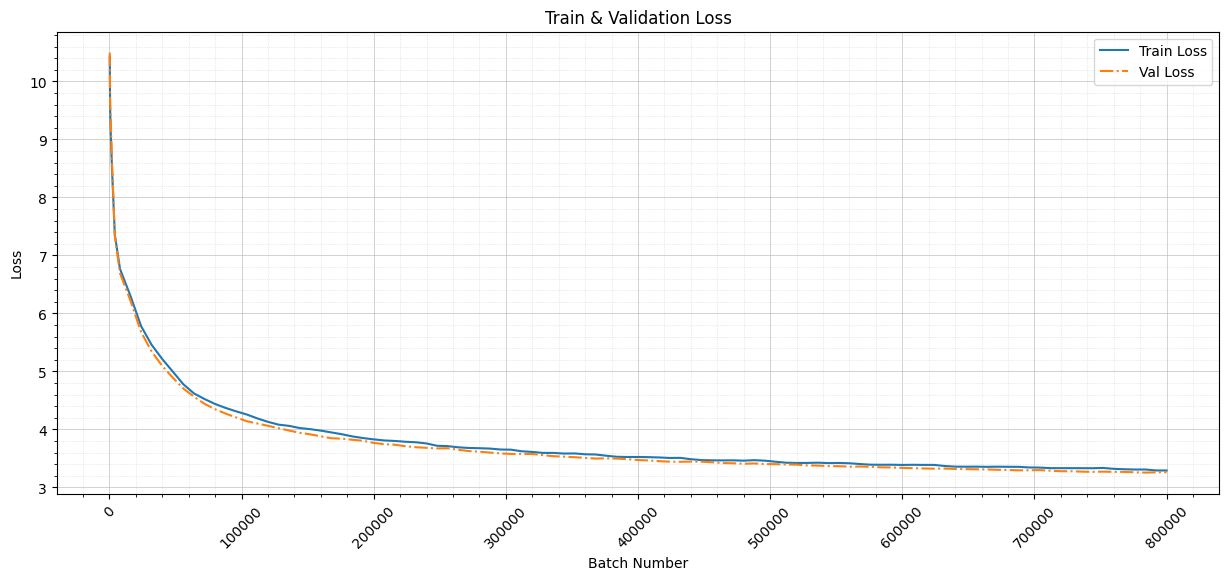

In [14]:
# -- Plot training and validation loss vs batch number ------------------------------------------------------
import matplotlib.pyplot as plt

def plot_train_val_loss(batches_seen, train_losses, val_losses):
    logger.info("Generating plot: training and validation loss vs batch number.")

    fig, ax1 = plt.subplots(figsize=(15,6))

    # Plot training and validation loss against epochs
    ax1.plot(batches_seen, train_losses, label="Train Loss")
    ax1.plot(batches_seen, val_losses, linestyle="-.", label="Val Loss")
    ax1.set_xlabel("Batch Number")
    #ax1.set_ylim(0)
    ax1.set_ylabel("Loss")
    ax1.set_title("Train & Validation Loss")
    ax1.legend(loc="upper right")
    # --- Add Subgrid (Minor Grid Lines) ---
    ax1.minorticks_on()  # Enable minor ticks
    # Major grid (main grid lines)
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.8)
    # Minor grid (subgrid lines)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax1.grid(True)

    #fig.tight_layout()  # Adjust layout to make room
    plt.xticks(rotation=45)
    plt.savefig(f"loss-plot-{run_id}.pdf")
    plt.show()

plot_train_val_loss(batches_seen, train_losses, val_losses)


In [16]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=40, temperature=1.3, top_k=20)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")

22:16:45 [INFO] Model output: 
I like apple juice - I drink it daily to keep track of blood pressure, especially if you are at home or if I get sick and then drink to check my urine to be sure I am up to my normal range.
I also


In [ ]:
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo

nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)
info = nvmlDeviceGetMemoryInfo(handle)

print(f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB")

Used: 12046 MB, Free: 241 MB, Total: 12288 MB


In [ ]:
# # Unload existing model to free up memory
# def cleanup_gpu():
#     try:
#         import gc, torch
#         del model
#         del optimizer
#         del scaler
#         # Delete all variables/tensors you used
#         for name in dir():
#             obj = globals().get(name)
#             if torch.is_tensor(obj) or (hasattr(obj, 'to') and callable(obj.to)):
#                 del obj
#         gc.collect()
#         torch.cuda.empty_cache()
#         torch.cuda.ipc_collect()
#         print("GPU memory cleanup complete.")
#     except NameError:
#         print("No previous model to unload.")


In [ ]:
# cleanup_gpu()

No previous model to unload.


In [13]:
# -- load model form checkpoint----------------------------------------------------

# 1) Re‑instantiate everything with the *same* hyperparameters
vocab_size = 50304
block_size = 1024
n_embd = 1024 # 768 1024 1280
n_head = 16 # 12 16 20
n_layer = 24 # 12 24 36
dropout = 0.1
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scaler = GradScaler(device, enabled=(device == 'cuda'))

# 2) Load tokenizer as before
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)

# 3) Point to your checkpoint
ckpt_path = r"outputs\output_v17\pre_training\run_1756251457\checkpoint_step_100000.pth"
assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"

# 4) Load the checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])

# # If you saved the scaler state dict, restore it
# if 'scaler_state_dict' in ckpt:
#     scaler.load_state_dict(ckpt['scaler_state_dict'])

# # When loading checkpoint:
# if 'warmup_scheduler_state_dict' in checkpoint:
#     warmup_scheduler.load_state_dict(checkpoint['warmup_scheduler_state_dict'])
# if 'plateau_scheduler_state_dict' in checkpoint:
#     scheduler.load_state_dict(checkpoint['plateau_scheduler_state_dict'])

# Load plot history
history = ckpt['history']
batches_seen = history['batches_seen']
train_losses = history['train_losses']
val_losses   = history['val_losses']

start_step = ckpt.get('epoch', None)
print(f"Loaded checkpoint from step {start_step}. Resuming from there.")

# 5) (Optional) Set model to eval or train
# For continued training:
model.train()
# For inference only:
# model.eval()

# 6) Example inference to verify it works:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=50, temperature=1.7, top_k=10)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")

Loaded checkpoint from step 100000. Resuming from there.


22:33:40 [INFO] Model output: 
I like apple juice - I drink it every night, especially at weekends and holidays. I have no doubt that it contains the highest levels of polyphenols.
But, as I have learned, polyphenols are actually a natural substance found naturally in fruits, berries and vegetables like berries
